# Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

import warnings
warnings.filterwarnings('ignore')

# Load data
signals_path = '2- Horizontal Signals.xlsx'
test_path = '3- Test Signal.txt'

df_signals = pd.read_excel(signals_path, header=None)

df_test = pd.read_table(test_path, header=None, names=['Signal'])

# Remove last row which is contains the name of the signal
signal_names = df_signals.iloc[-1].tolist()
df_signals = df_signals.iloc[:-1]

print("Horizontal Signals Shape:", df_signals.shape)
print("Test Signal Shape:", df_test.shape)

df_signals.head()

Horizontal Signals Shape: (250, 20)
Test Signal Shape: (250, 1)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,151,151,161,143,152,134,127,123,138,135,139,122,126,129,125,129,135,139,135,133
1,145,146,163,136,147,141,133,132,131,136,145,133,127,131,122,135,130,131,127,134
2,146,146,164,136,152,138,137,135,132,138,149,130,122,138,127,138,134,135,134,132
3,151,152,158,141,151,131,130,124,140,133,145,123,126,131,126,133,136,134,136,131
4,151,147,161,137,148,139,129,132,133,135,141,132,130,131,121,131,129,137,128,133


# Visualization

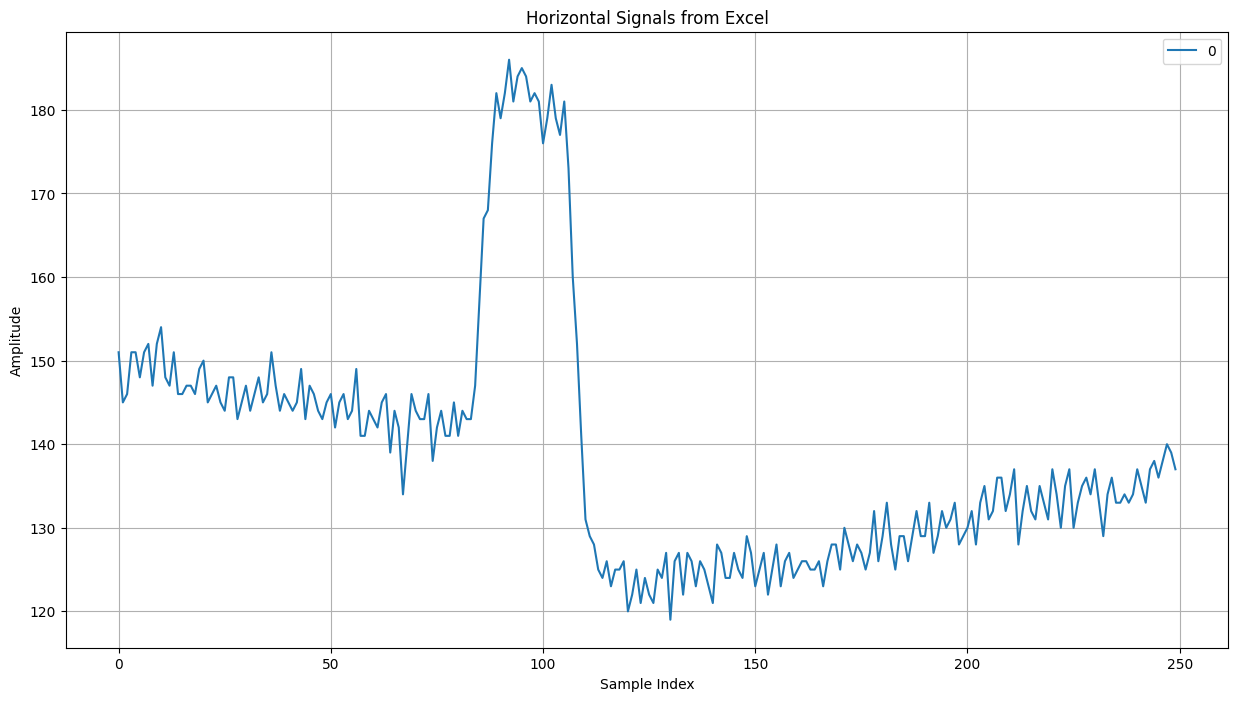

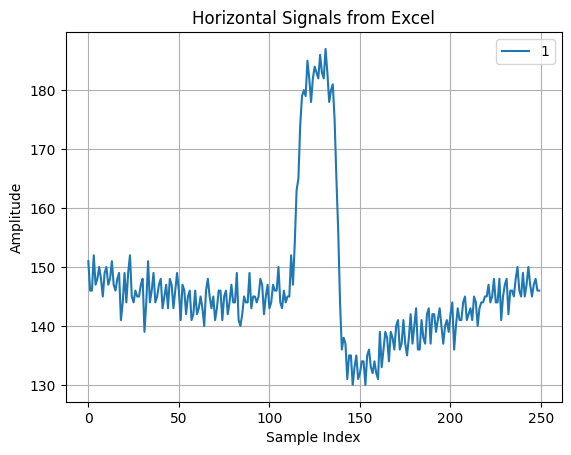

In [2]:

plt.figure(figsize=(15, 8))
for column in df_signals.columns[:2]:
    signal = df_signals[column]
    plt.plot(signal, label=column)
    plt.title('Horizontal Signals from Excel')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()



# Preprocessing

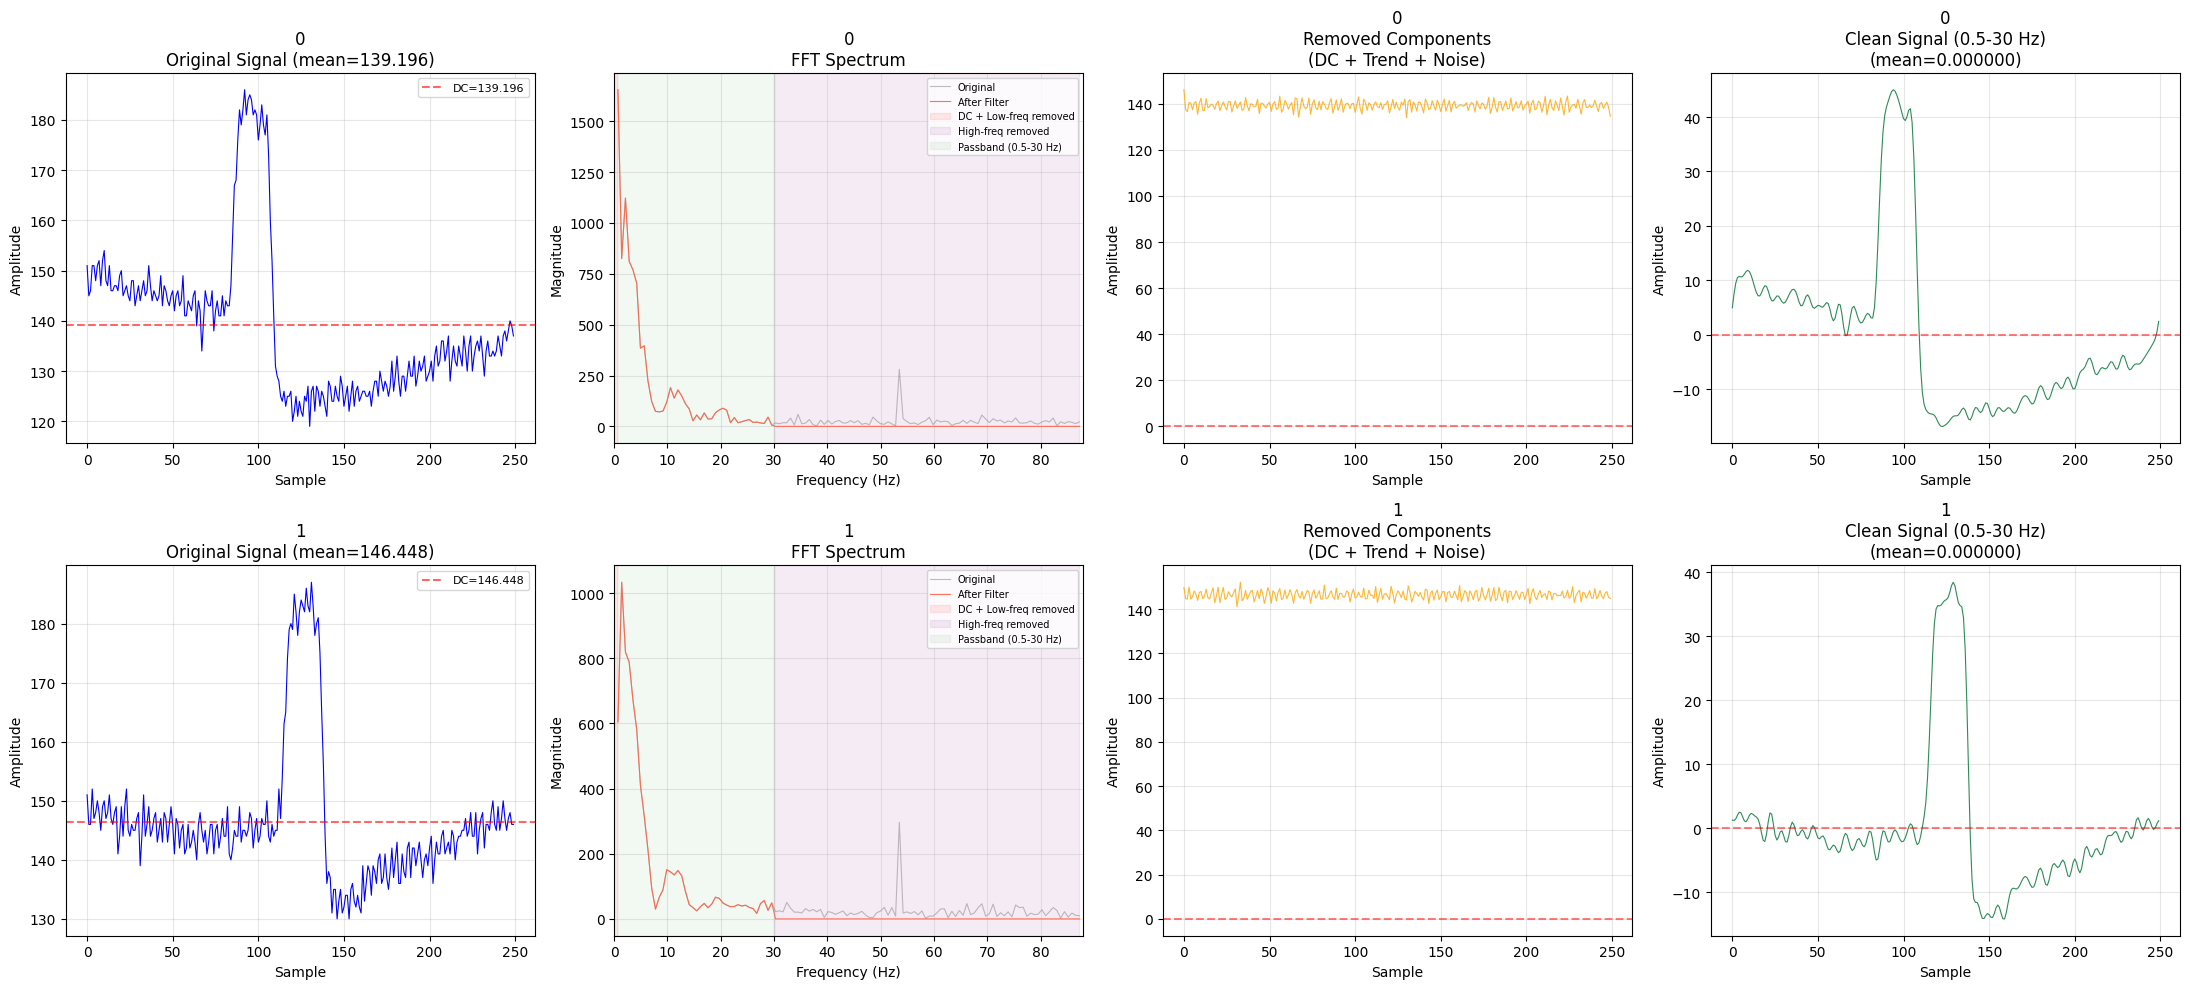

✅ Preprocessing complete!
   Passband : 0.5 Hz - 30 Hz
   Shape    : (250, 20)
   NaN check: 0 NaNs remaining


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import butter, filtfilt
import pywt

sampling_rate = 176
n = len(df_signals)
frequencies = fftfreq(n, d=1/sampling_rate)

def apply_bandpass_filter(signal_data, lowcut, highcut, fs, order=4):
    """Utility function to apply a Butterworth Bandpass Filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, signal_data)
    return y


def preprocess_signal_mean(signal_raw, sampling_rate):
    """
    Preprocessing Pipeline:
      1. Remove DC using Time-Domain Mean Removal
      2. Apply Butterworth Bandpass Filter (0.5 - 30 Hz)
    """
    n = len(signal_raw)
    freqs = fftfreq(n, d=1/sampling_rate)

    # --- Safety: cast to float64 and handle NaN ---
    signal = signal_raw.astype(np.float64)
    signal = signal.fillna(signal.mean())
    signal_vals = signal.values

    # --- Step 1: Remove DC using mean subtraction ---
    signal_no_dc = signal_vals - np.mean(signal_vals)

    # --- Step 2: Apply Butterworth Bandpass Filter [0.5, 30] Hz ---
    signal_clean = apply_bandpass_filter(signal_no_dc, 0.5, 30.0, sampling_rate, order=4)

    # --- Step 3: Normalization (Z-score) ---
    # std_val = np.std(signal_clean)
    # if std_val > 0:
    #     signal_clean = (signal_clean - np.mean(signal_clean)) / std_val

    # --- Generate FFT values purely for plotting compatability ---
    fft_values = fft(signal_vals)
    fft_clean  = fft(signal_clean)

    return signal_vals, fft_values, fft_clean, freqs, signal_clean

def preprocess_signal_fft(signal_raw, sampling_rate):
    """
    Full FFT-based preprocessing:
      1. Remove DC component        (zero out bin[0])
      2. Remove low-freq trends     (zero out bins below 0.5 Hz)
      3. Remove high-freq noise     (zero out bins above 30 Hz)
      → Result: clean bandpass signal between 0.5 - 30 Hz
    """
    n = len(signal_raw)
    freqs = fftfreq(n, d=1/sampling_rate)

    # --- Safety: cast to float64 and handle NaN ---
    signal = signal_raw.astype(np.float64)
    signal = signal.fillna(signal.mean())
    signal_vals = signal.values

    # --- Step 1: FFT ---
    fft_values = fft(signal_vals)
    fft_clean  = fft_values.copy()

    # --- Step 2: Remove DC component (0 Hz bin) ---
    fft_clean[0] = 0

    # --- Step 3: Remove low-frequency trends (< 0.5 Hz) ---
    low_cut  = 0.5   # Hz
    fft_clean[np.abs(freqs) < low_cut] = 0

    # --- Step 4: Remove high-frequency noise (> 30 Hz) ---
    high_cut = 30.0  # Hz
    fft_clean[np.abs(freqs) > high_cut] = 0

    # --- Step 5: Reconstruct via Inverse FFT ---
    signal_clean = np.real(ifft(fft_clean))

    # --- Step 6: Normalization (Z-score) ---
    # std_val = np.std(signal_clean)
    # if std_val > 0:
    #     signal_clean = (signal_clean - np.mean(signal_clean)) / std_val

    return signal_vals, fft_values, fft_clean, freqs, signal_clean

def preprocess_signal(signal_raw, sampling_rate):
    """
    Main dispatch function.
    Change the returned function here to switch between different methods:
    - preprocess_signal_fft
    - preprocess_signal_mean
    """
    
    return preprocess_signal_fft(signal_raw, sampling_rate)


# ── Plotting ────────────────────────────────────────────────────────────────
SIGNALS_TO_PLOT = 2
fig, axes = plt.subplots(SIGNALS_TO_PLOT, 4, figsize=(22, 5 * SIGNALS_TO_PLOT))

if len(df_signals.columns) == 1:
    axes = axes.reshape(1, -1)

for i, column in enumerate(df_signals.columns):

    signal_vals, fft_orig, fft_clean, freqs, signal_clean = preprocess_signal(
        df_signals[column], sampling_rate
    )
    
    signal = signal_vals # Map inner naming to plotting logic

    positive_idx = freqs > 0
    if i < SIGNALS_TO_PLOT:
        # ── Plot 1: Original Signal ──────────────────────────────────────────
        axes[i, 0].plot(signal, color='blue', linewidth=0.8)
        axes[i, 0].set_title(f'{column}\nOriginal Signal (mean={signal.mean():.3f})')
        axes[i, 0].axhline(signal.mean(), color='red', linestyle='--', alpha=0.6, label=f'DC={signal.mean():.3f}')
        axes[i, 0].set_xlabel('Sample')
        axes[i, 0].set_ylabel('Amplitude')
        axes[i, 0].legend(fontsize=8)
        axes[i, 0].grid(True, alpha=0.3)

        # ── Plot 2: FFT Spectrum — Before vs After ───────────────────────────
        axes[i, 1].plot(freqs[positive_idx], np.abs(fft_orig)[positive_idx],
                        color='gray',   alpha=0.5, linewidth=0.8, label='Original')
        axes[i, 1].plot(freqs[positive_idx], np.abs(fft_clean)[positive_idx],
                        color='tomato', alpha=0.9, linewidth=0.8, label='After Filter')
        axes[i, 1].axvspan(0,    0.5,  color='red',    alpha=0.08, label='DC + Low-freq removed')
        axes[i, 1].axvspan(30,   freqs.max(), color='purple', alpha=0.08, label='High-freq removed')
        axes[i, 1].axvspan(0.5,  30,   color='green',  alpha=0.05, label='Passband (0.5-30 Hz)')
        axes[i, 1].set_title(f'{column}\nFFT Spectrum')
        axes[i, 1].set_xlabel('Frequency (Hz)')
        axes[i, 1].set_ylabel('Magnitude')
        axes[i, 1].set_xlim(0, sampling_rate / 2)
        axes[i, 1].legend(fontsize=7)
        axes[i, 1].grid(True, alpha=0.3)

        # ── Plot 3: What was removed ─────────────────────────────────────────
        noise_removed = signal - signal_clean
        axes[i, 2].plot(noise_removed, color='orange', linewidth=0.8, alpha=0.8)
        axes[i, 2].set_title(f'{column}\nRemoved Components\n(DC + Trend + Noise)')
        axes[i, 2].set_xlabel('Sample')
        axes[i, 2].set_ylabel('Amplitude')
        axes[i, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
        axes[i, 2].grid(True, alpha=0.3)

        # ── Plot 4: Clean Signal ─────────────────────────────────────────────
        axes[i, 3].plot(signal_clean, color='seagreen', linewidth=0.8)
        axes[i, 3].set_title(f'{column}\nClean Signal (0.5-30 Hz)\n(mean={signal_clean.mean():.6f})')
        axes[i, 3].set_xlabel('Sample')
        axes[i, 3].set_ylabel('Amplitude')
        axes[i, 3].axhline(0, color='red', linestyle='--', alpha=0.5)
        axes[i, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Save cleaned signals to DataFrame ───────────────────────────────────────
df_signals_clean = pd.DataFrame(
    {col: preprocess_signal(df_signals[col], sampling_rate)[4]
     for col in df_signals.columns},
    index=df_signals.index
)

print("✅ Preprocessing complete!")
print(f"   Passband : 0.5 Hz - 30 Hz")
print(f"   Shape    : {df_signals_clean.shape}")
print(f"   NaN check: {df_signals_clean.isna().sum().sum()} NaNs remaining")

# Feature Extraction

In [4]:
import numpy as np
import pandas as pd
from scipy.integrate import simpson
from statsmodels.tsa.ar_model import AutoReg

def extract_features(signal_data, signal_name="Signal"):
    """
    Extracts statistical, morphological, and AR features for a single 1D signal.
    """
    signal_data = signal_data.dropna().values if isinstance(signal_data, pd.Series) else np.asarray(signal_data)
    signal_data = signal_data[~np.isnan(signal_data)] # remove NaNs if any
    
    if len(signal_data) == 0:
        return None
        
    # Statistical features
    mean_val = np.mean(signal_data)
    std_val = np.std(signal_data)
    
    # Morphological features
    max_peak = np.max(signal_data)
    auc_val = simpson(np.abs(signal_data)) # Simpson's rule for Area Under the Curve (AUC)
    
    # Auto-regression features "3 coefficients"
    try:
        ar_model = AutoReg(signal_data, lags=2).fit()
        ar_coeffs = ar_model.params[0:] 
        
        if len(ar_coeffs) < 3:
            ar_coeffs = np.pad(ar_coeffs, (0, 3 - len(ar_coeffs)), constant_values=np.nan)
    except Exception:
        ar_coeffs = [np.nan, np.nan, np.nan]
        
    return {
        'Signal': signal_name,
        'Mean': mean_val,
        'Std': std_val,
        'Max_Peak': max_peak,
        'AUC': auc_val,
        'B': ar_coeffs[0],
        'W_1': ar_coeffs[1],
        'W_2': ar_coeffs[2]
    }

# 1. Apply to all signals in df_signals_clean
print(df_signals_clean.shape)
feature_list = []

for i, col in enumerate(df_signals_clean.columns):
    
    features = extract_features(df_signals_clean[col], signal_name=signal_names[i])
    if features:
        feature_list.append(features)
    

df_features = pd.DataFrame(feature_list)
df_features.to_excel('matrix_features.xlsx', index=False)
print("Features successfully extracted and saved to matrix_features.xlsx")
df_features.head()

# 2. You can also apply it to your test signal if you want!
# test_features = extract_features(df_test['Signal'], signal_name="Test_Signal")
# print("Test Signal Features:", test_features)



(250, 20)
Features successfully extracted and saved to matrix_features.xlsx


,Signal,Mean,Std,Max_Peak,AUC,B,W_1,W_2
0,Adam,0.000000e+00,14.964430,45.016300,2836.839058,-0.004492,1.898596,-0.912546
1,Layan,0.000000e+00,11.319238,38.405127,1631.010714,0.001635,1.866318,-0.886043
2,Zayn,0.000000e+00,22.286026,29.822708,4991.127674,-0.027445,1.738472,-0.745242
3,Mayar,-1.307399e-15,18.441779,43.506185,3391.354196,0.003169,1.908525,-0.916414
4,Rayyan,2.273737e-16,10.868609,32.513499,1998.970161,-0.000392,1.883307,-0.898953


# Classification of EOG signals Using Ecludian Distance

In [5]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean

# --- 1. Preprocess and Extract Features for the Test Signal ---

raw_test_signal = pd.to_numeric(df_test['Signal'], errors='coerce').dropna()

# Preprocess the test signal using your existing function

clean_test_signal = preprocess_signal(raw_test_signal, sampling_rate)[4]

# Extract features using the function we defined earlier
test_features = extract_features(clean_test_signal, signal_name="Test_Signal")
df_test_features = pd.DataFrame([test_features])

# --- 2. Prepare Data for Distance Calculation ---

feature_cols = ['Mean', 'Std', 'Max_Peak', 'AUC', 'B', 'W_1', 'W_2']

X_train = df_features[feature_cols].values
X_test = df_test_features[feature_cols].values



# train_mean = np.mean(X_train, axis=0)
# train_std = np.std(X_train, axis=0)
# train_std[train_std == 0] = 1e-10  # Prevent division by zero

# X_train_scaled = (X_train - train_mean) / train_std
# X_test_scaled = (X_test - train_mean) / train_std

X_train_scaled = X_train
X_test_scaled = X_test

# --- 3. Compute Euclidean Distance and Classify ---
distances = []
for i in range(len(X_train_scaled)):
    dist = euclidean(X_test_scaled[0], X_train_scaled[i])
    distances.append(dist)

# Store results in a new DataFrame to find the best match
df_results = df_features[['Signal']].copy()
df_results['Distance'] = distances

# Sort by the shortest distance
df_results = df_results.sort_values(by='Distance').reset_index(drop=True)

best_match = df_results.iloc[0]

# --- 4. Display Results ---
print(f"✅ Classification Complete!")
print(f"🏆 The Test Signal is classified as: '{best_match['Signal']}'")
print(f"📏 Euclidean Distance to match: {best_match['Distance']:.4f}\n")

# print("Top 5 Closest Matches:")
df_results.head(20)


✅ Classification Complete!
🏆 The Test Signal is classified as: 'Juri'
📏 Euclidean Distance to match: 0.0000



,Signal,Distance
0,Juri,0.000000
1,Rayyan,291.329213
2,Faris,454.927739
3,Kian,476.946981
4,Adam,547.846582
5,Tala,618.085377
6,Ayla,648.363650
7,Layan,659.179423
8,Hamza,840.807459
9,Mayar,1101.931024
